### Load packages

In [38]:
import pandas as pd
import os
import textwrap
import numpy as np

# for figures
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.dates as mdates
import seaborn as sns
import geopandas as gpd
from shapely.geometry import Point
from pandas.plotting import scatter_matrix

### Set project parameters for this run

In [39]:
# Project parameters

data_directory = r"..\data\merged_csvs"

algae_file = "algae_merged"
algae_path = os.path.join(data_directory, algae_file + ".csv")
print(algae_path)

..\data\merged_csvs\algae_merged.csv


### Load algae bloom data

In [40]:
# Load algae bloom data file

algae_raw_df = pd.read_csv(algae_path)

In [41]:
algae_raw_df.iloc[:5, :]
# vct_raw_df.iloc[:10, 10:25]
# vct_raw_df.iloc[:10, 10:25]

,vct_region,vct_report_date,vct_latitude,vct_longitude,vct_water_temp_trailing,vct_water_surface_trailing,vct_anabaena_trailing,vct_aphanizomenon_trailing,vct_microcystin_trailing,vct_oscillatoria_trailing,...,noaa_WDF5,noaa_TAVG,dec_total nitrogen,dec_total phosphorus,dec_dissolved phosphorus,dec_chlorophyll-a,dec_secchi depth,dec_temperature,vct_target_bloom,vct_target_bloom_intensity
0,Main Lake Central,2014-09-30,44.484736,-73.288936,66.608333,Calm,1.0,1.0,0.0,1.0,...,211.428571,15.228571,0.340,12.5,5.00,3.830,5.40,NaN,0,1a
1,Main Lake Central,2014-10-02,44.484736,-73.288936,66.169167,Calm,1.0,1.0,0.0,1.0,...,233.571429,15.328571,0.340,12.5,5.00,3.830,5.40,NaN,1,3
2,Main Lake Central,2015-06-14,44.484736,-73.288936,65.625000,Calm,1.0,0.0,0.0,0.0,...,254.285714,16.521429,0.400,69.6,13.00,2.300,5.00,12.0,0,1b
3,Main Lake Central,2015-06-15,44.484736,-73.288936,65.597222,Calm,1.0,0.0,0.0,0.0,...,250.000000,16.992857,0.400,69.6,13.00,2.300,5.00,12.0,0,1a
4,Main Lake Central,2015-06-16,44.484736,-73.288936,65.347222,Calm,1.0,0.0,0.0,0.0,...,252.142857,17.557143,0.405,39.7,9.65,1.815,4.05,14.2,0,1a


In [42]:
print(len(algae_raw_df.columns))
algae_raw_df.columns

35


Index(['vct_region', 'vct_report_date', 'vct_latitude', 'vct_longitude',
       'vct_water_temp_trailing', 'vct_water_surface_trailing',
       'vct_anabaena_trailing', 'vct_aphanizomenon_trailing',
       'vct_microcystin_trailing', 'vct_oscillatoria_trailing',
       'usgs_water_temp_max_trailing', 'usgs_water_temp_min_trailing',
       'usgs_water_temp_mean_trailing', 'usgs_conductivity_max_trailing',
       'usgs_conductivity_min_trailing', 'usgs_conductivity_mean_trailing',
       'noaa_PRCP', 'noaa_TMAX', 'noaa_TMIN', 'noaa_AWND', 'noaa_WSF2',
       'noaa_SNWD', 'noaa_WDF2', 'noaa_SNOW', 'noaa_WSF5', 'noaa_WDF5',
       'noaa_TAVG', 'dec_total nitrogen', 'dec_total phosphorus',
       'dec_dissolved phosphorus', 'dec_chlorophyll-a', 'dec_secchi depth',
       'dec_temperature', 'vct_target_bloom', 'vct_target_bloom_intensity'],
      dtype='object')

In [43]:
# Convert number columns to floats and integers as appropriate

algae_numcols_df = algae_raw_df.copy()

float_cols = ["vct_water_temp_trailing", "usgs_water_temp_max_trailing", "usgs_water_temp_min_trailing", "usgs_water_temp_mean_trailing", 
              "usgs_conductivity_max_trailing", "usgs_conductivity_min_trailing", "usgs_conductivity_mean_trailing",
              "noaa_PRCP", "noaa_TMIN", "noaa_TMAX", "noaa_AWND", "noaa_WDF2", "noaa_WSF2", "noaa_SNWD", "noaa_SNOW",
              "noaa_WSF5", "noaa_WDF5", "noaa_TAVG", "dec_total nitrogen", "dec_total phosphorus", "dec_dissolved phosphorus",
              "dec_chlorophyll-a", "dec_secchi depth", "dec_temperature"]
int_cols = ["vct_anabaena_trailing", "vct_aphanizomenon_trailing", "vct_microcystin_trailing", "vct_oscillatoria_trailing",
             "vct_target_bloom"]

algae_numcols_df[float_cols] = algae_numcols_df[float_cols].apply(pd.to_numeric, errors="coerce")

algae_numcols_df[int_cols] = (algae_numcols_df[int_cols].apply(pd.to_numeric, errors="coerce").astype("Int64"))

algae_numcols_df.head()

,vct_region,vct_report_date,vct_latitude,vct_longitude,vct_water_temp_trailing,vct_water_surface_trailing,vct_anabaena_trailing,vct_aphanizomenon_trailing,vct_microcystin_trailing,vct_oscillatoria_trailing,...,noaa_WDF5,noaa_TAVG,dec_total nitrogen,dec_total phosphorus,dec_dissolved phosphorus,dec_chlorophyll-a,dec_secchi depth,dec_temperature,vct_target_bloom,vct_target_bloom_intensity
0,Main Lake Central,2014-09-30,44.484736,-73.288936,66.608333,Calm,1,1,0,1,...,211.428571,15.228571,0.340,12.5,5.00,3.830,5.40,NaN,0,1a
1,Main Lake Central,2014-10-02,44.484736,-73.288936,66.169167,Calm,1,1,0,1,...,233.571429,15.328571,0.340,12.5,5.00,3.830,5.40,NaN,1,3
2,Main Lake Central,2015-06-14,44.484736,-73.288936,65.625000,Calm,1,0,0,0,...,254.285714,16.521429,0.400,69.6,13.00,2.300,5.00,12.0,0,1b
3,Main Lake Central,2015-06-15,44.484736,-73.288936,65.597222,Calm,1,0,0,0,...,250.000000,16.992857,0.400,69.6,13.00,2.300,5.00,12.0,0,1a
4,Main Lake Central,2015-06-16,44.484736,-73.288936,65.347222,Calm,1,0,0,0,...,252.142857,17.557143,0.405,39.7,9.65,1.815,4.05,14.2,0,1a


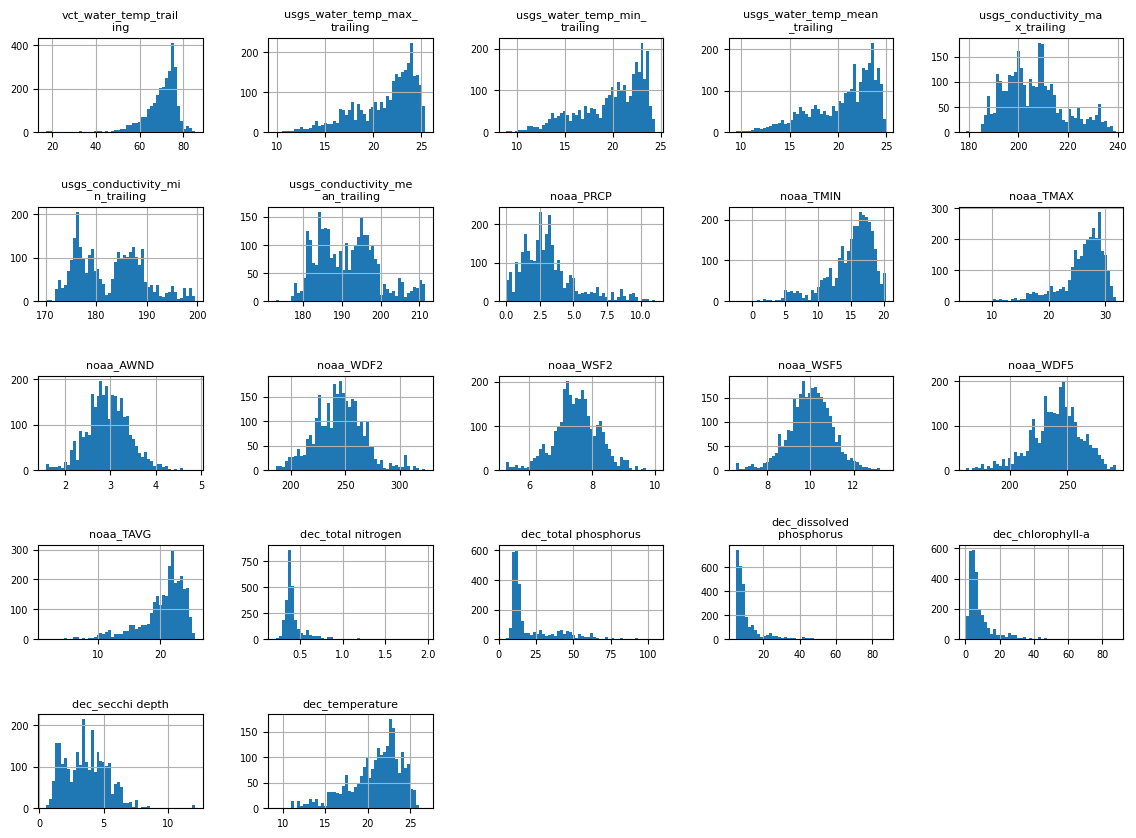

In [44]:
# Plot histograms of the numerical columns in the data

use_log_values = False

histo_cols = ["vct_water_temp_trailing", "usgs_water_temp_max_trailing", "usgs_water_temp_min_trailing", "usgs_water_temp_mean_trailing", 
              "usgs_conductivity_max_trailing", "usgs_conductivity_min_trailing", "usgs_conductivity_mean_trailing",
              "noaa_PRCP", "noaa_TMIN", "noaa_TMAX", "noaa_AWND", "noaa_WDF2", "noaa_WSF2",
              "noaa_WSF5", "noaa_WDF5", "noaa_TAVG", "dec_total nitrogen", "dec_total phosphorus", "dec_dissolved phosphorus",
              "dec_chlorophyll-a", "dec_secchi depth", "dec_temperature"]

plot_df =  algae_numcols_df[histo_cols].apply(pd.to_numeric, errors="coerce")

# Compute logs if needed
if use_log_values:
    safe_plot_df = plot_df.where(plot_df > -1)
    safe_plot_df = np.log10(safe_plot_df + 1)
else:
    safe_plot_df = plot_df.copy()

# drop columns that are all nulls or NaN values
safe_plot_df = safe_plot_df.dropna(axis=1, how="all")

axes = safe_plot_df.hist(bins=50, figsize=(14, 10), layout=(5, 5))

for ax in axes.flatten():
    title = ax.get_title()
    wrapped_title = "\n".join(textwrap.wrap(title, width=20))
    ax.set_title(wrapped_title, fontsize=8)
    ax.tick_params(axis="y", labelsize=7)
    ax.tick_params(axis="x", labelsize=7)

plt.subplots_adjust(hspace=0.8, wspace=0.4)

plt.show()


In [45]:
algae_numcols_df.columns

Index(['vct_region', 'vct_report_date', 'vct_latitude', 'vct_longitude',
       'vct_water_temp_trailing', 'vct_water_surface_trailing',
       'vct_anabaena_trailing', 'vct_aphanizomenon_trailing',
       'vct_microcystin_trailing', 'vct_oscillatoria_trailing',
       'usgs_water_temp_max_trailing', 'usgs_water_temp_min_trailing',
       'usgs_water_temp_mean_trailing', 'usgs_conductivity_max_trailing',
       'usgs_conductivity_min_trailing', 'usgs_conductivity_mean_trailing',
       'noaa_PRCP', 'noaa_TMAX', 'noaa_TMIN', 'noaa_AWND', 'noaa_WSF2',
       'noaa_SNWD', 'noaa_WDF2', 'noaa_SNOW', 'noaa_WSF5', 'noaa_WDF5',
       'noaa_TAVG', 'dec_total nitrogen', 'dec_total phosphorus',
       'dec_dissolved phosphorus', 'dec_chlorophyll-a', 'dec_secchi depth',
       'dec_temperature', 'vct_target_bloom', 'vct_target_bloom_intensity'],
      dtype='object')

In [46]:
# Find counts for all the categorical columns

cat_cols = ["vct_region", 
            "vct_water_surface_trailing",
            "vct_anabaena_trailing",
            "vct_aphanizomenon_trailing",
            "vct_microcystin_trailing",
            "vct_oscillatoria_trailing",
            "vct_target_bloom",
            "vct_target_bloom_intensity"
]

for col in cat_cols:
    print(algae_numcols_df[col].value_counts(), "\n")


vct_region
Main Lake Central    897
Main Lake South      767
St. Albans Bay       477
Missisquoi Bay       424
Malletts Bay         354
Name: count, dtype: int64 

vct_water_surface_trailing
Calm          2367
Rolling        550
White Caps       2
Name: count, dtype: int64 

vct_anabaena_trailing
1    1730
0    1189
Name: count, dtype: Int64 

vct_aphanizomenon_trailing
1    1996
0     923
Name: count, dtype: Int64 

vct_microcystin_trailing
1    1498
0    1421
Name: count, dtype: Int64 

vct_oscillatoria_trailing
0    2438
1     481
Name: count, dtype: Int64 

vct_target_bloom
0    2210
1     709
Name: count, dtype: Int64 

vct_target_bloom_intensity
1a    921
1c    513
1b    472
3     422
1d    304
2     287
Name: count, dtype: int64 



In [47]:
# Format the data for time plots

vct_bloom_df["report_date"] = pd.to_datetime(vct_bloom_df["report_date"])
vct_bloom_df["year"] = vct_bloom_df["report_date"].dt.year

# vct_bloom_mainlake_df = vct_bloom_df[vct_bloom_df["region"] == "champlain - main lake central"]

# Count records per date per year
date_counts = (
    vct_bloom_df
    .groupby(["year", "report_date"])
    .size()
    .reset_index(name="count")
)

NameError: name 'vct_bloom_df' is not defined

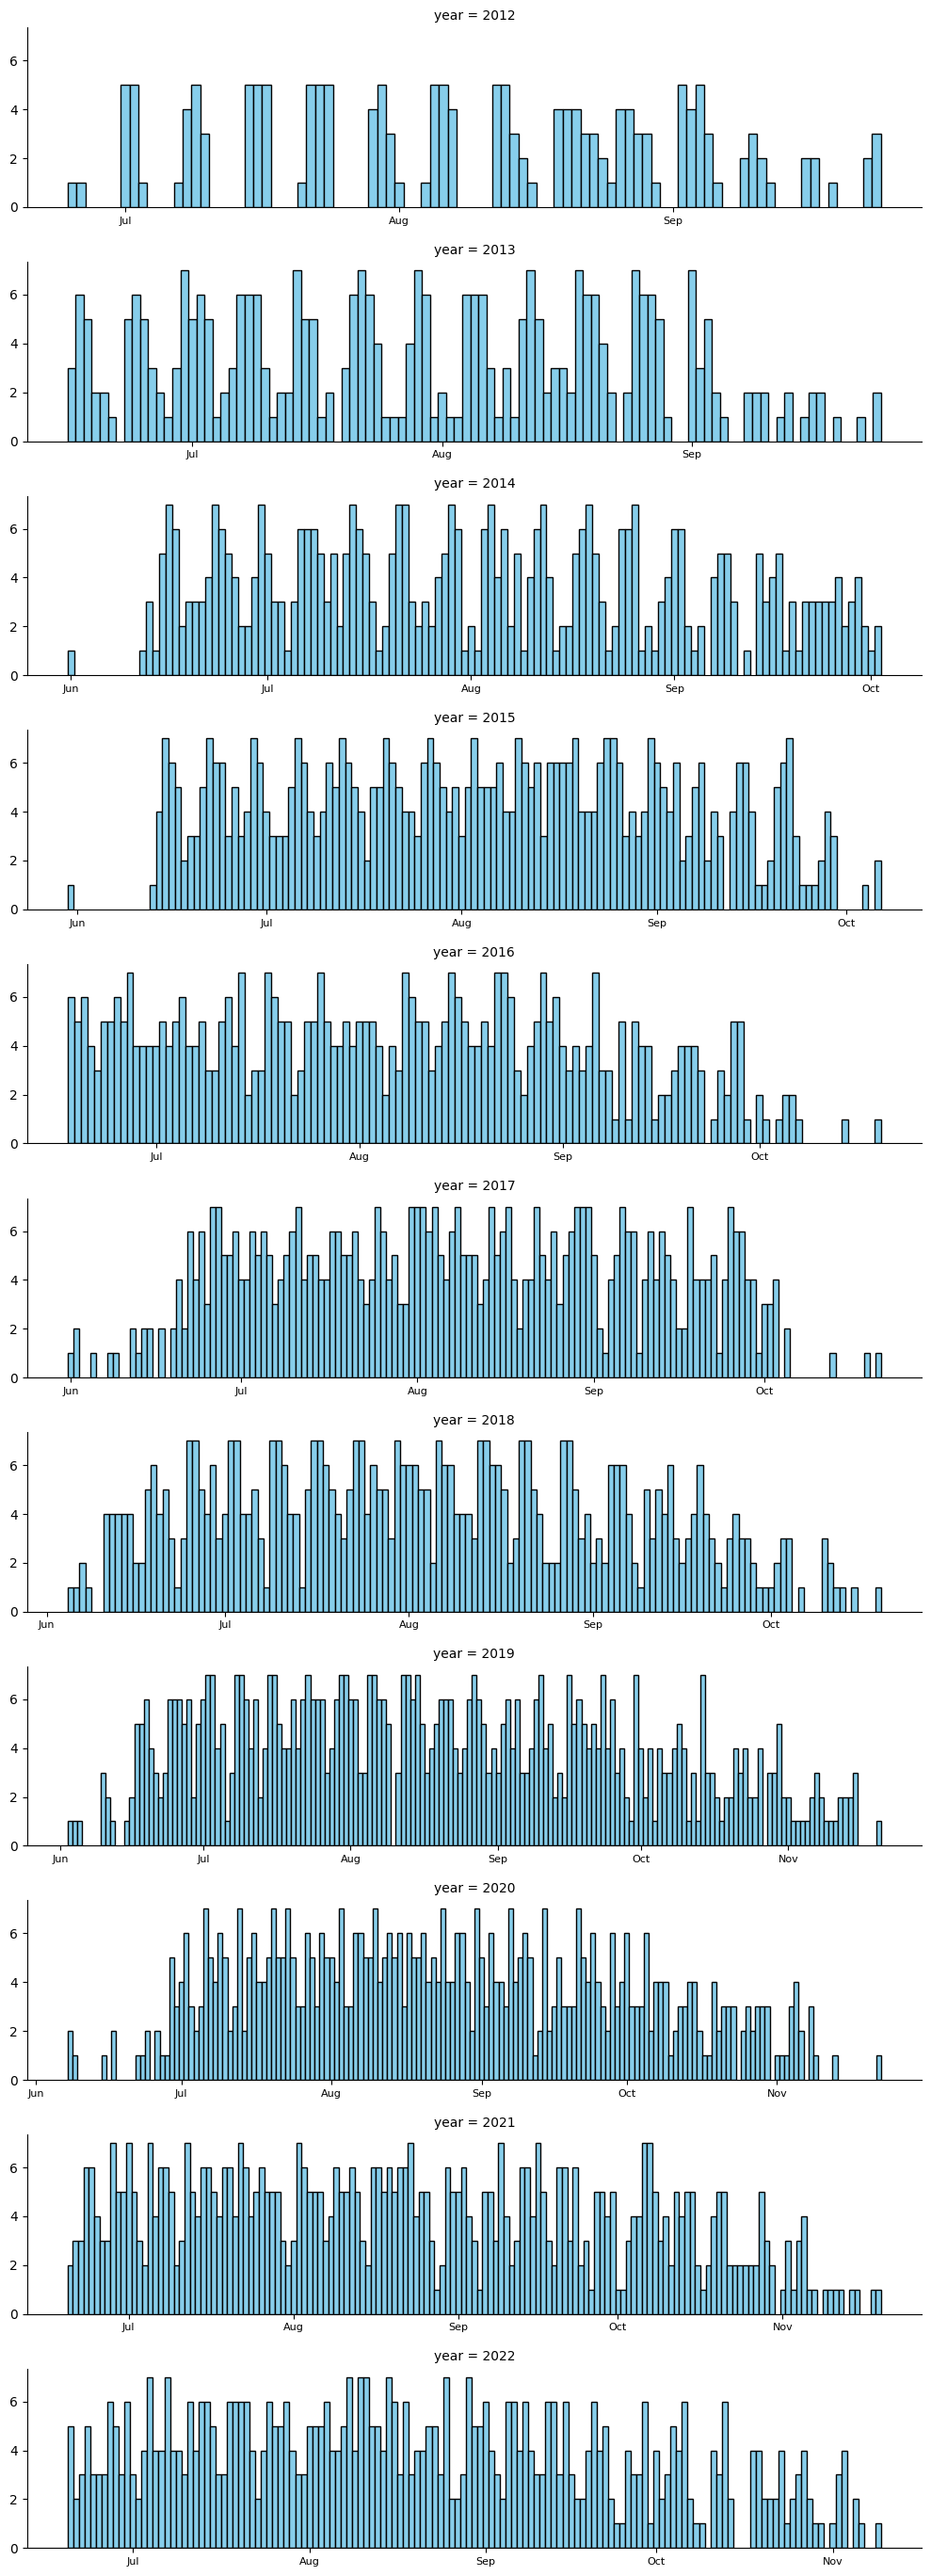

In [ ]:
# Time plot - bar graphs per year

def barplot_datetime(data, **kwargs):
    ax = plt.gca()
    ax.bar(
        data["report_date"],
        data["count"],
        color="skyblue",
        edgecolor="black",
        width=1
    )

g = sns.FacetGrid(
    date_counts,
    row="year",
    height=2.5,
    aspect=4,
    sharex=False
)

g.map_dataframe(barplot_datetime)

for ax in g.axes.flat:
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
    ax.tick_params(axis="x", labelsize=8)
    ax.set_xlabel("")
    ax.set_ylabel("")


In [ ]:
# Compute correlation coefficients for every number variable

corr_cols = ["feature_water_temp", "feature_anabaena", "feature_aphanizomenon",
             "feature_microcystin", "feature_oscillatoria"]

corr_matrix = vct_bloom_df[corr_cols].corr()

for corr_col in corr_cols:
    print(corr_matrix[corr_col].sort_values(ascending=False).round(2), "\n")


feature_water_temp       1.00
feature_anabaena         0.11
feature_oscillatoria     0.03
feature_aphanizomenon   -0.03
feature_microcystin     -0.07
Name: feature_water_temp, dtype: float64 

feature_anabaena         1.00
feature_aphanizomenon    0.56
feature_microcystin      0.43
feature_oscillatoria     0.18
feature_water_temp       0.11
Name: feature_anabaena, dtype: float64 

feature_aphanizomenon    1.00
feature_anabaena         0.56
feature_microcystin      0.54
feature_oscillatoria     0.14
feature_water_temp      -0.03
Name: feature_aphanizomenon, dtype: float64 

feature_microcystin      1.00
feature_aphanizomenon    0.54
feature_anabaena         0.43
feature_oscillatoria     0.13
feature_water_temp      -0.07
Name: feature_microcystin, dtype: float64 

feature_oscillatoria     1.00
feature_anabaena         0.18
feature_aphanizomenon    0.14
feature_microcystin      0.13
feature_water_temp       0.03
Name: feature_oscillatoria, dtype: float64 



C:\Users\hefla\AppData\Local\Temp\ipykernel_6420\3838340879.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agg_df = plot_df.groupby("temp_bin")[y_cols].sum().reset_index()


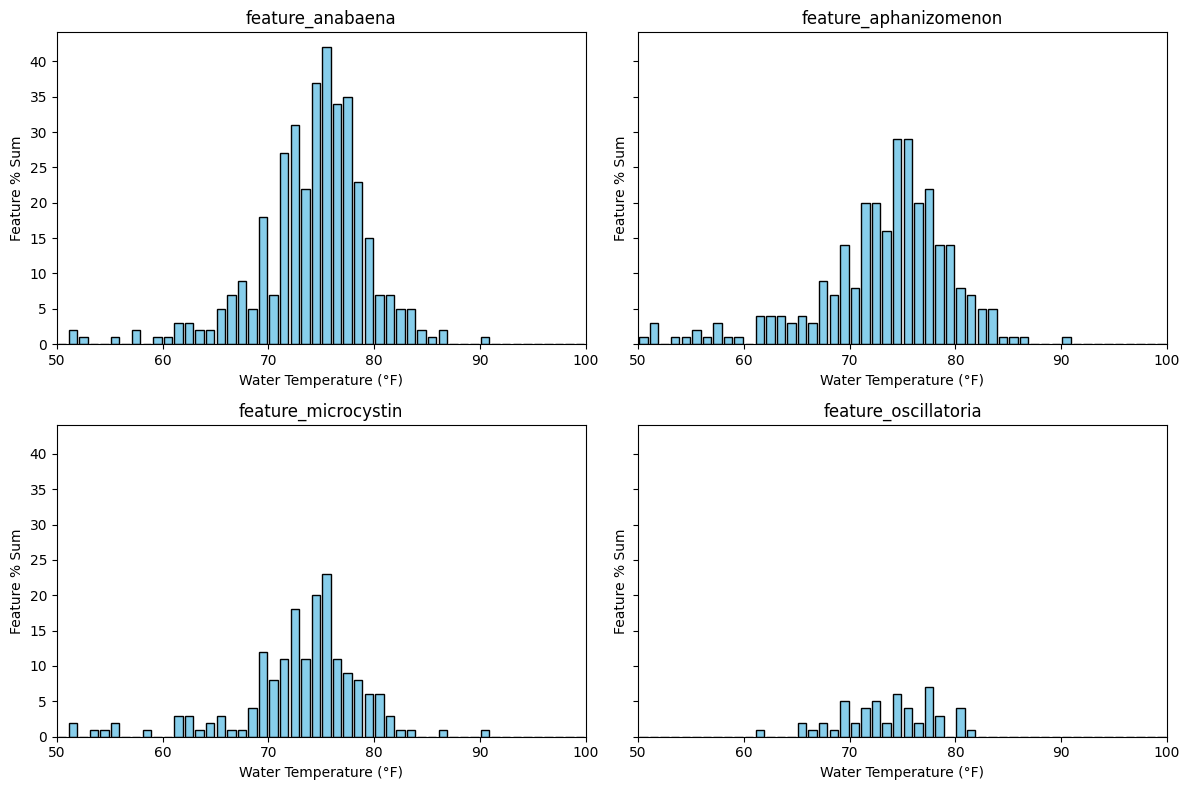

In [ ]:
# Columns to plot
y_cols = ["feature_anabaena", "feature_aphanizomenon",
          "feature_microcystin", "feature_oscillatoria"]

# Ensure numeric
plot_df = vct_bloom_df[["feature_water_temp"] + y_cols].apply(pd.to_numeric, errors="coerce")

# Filter for temperature range 50–100
plot_df = plot_df[(plot_df["feature_water_temp"] >= 50) & (plot_df["feature_water_temp"] <= 100)]

# Bin the temperature finely (1-degree bins)
bin_width = 1
bins = np.arange(50, 101, bin_width)
plot_df["temp_bin"] = pd.cut(plot_df["feature_water_temp"], bins=bins, include_lowest=True)

# Aggregate: sum per temperature bin (or use mean)
agg_df = plot_df.groupby("temp_bin")[y_cols].sum().reset_index()

# Convert bin to midpoint for continuous x-axis
agg_df["temp_mid"] = agg_df["temp_bin"].apply(lambda x: x.left + bin_width/2)

# Find max value across all features for consistent y-axis
y_max = agg_df[y_cols].max().max()

# Plot each feature as a bar with shared y-axis
fig, axes = plt.subplots(2, 2, figsize=(12,8), sharey=True)
axes = axes.flatten()

for ax, col in zip(axes, y_cols):
    ax.bar(agg_df["temp_mid"], agg_df[col], width=bin_width*0.8, color="skyblue", edgecolor="black")
    ax.set_xlim(50, 100)
    ax.set_ylim(0, y_max*1.05)  # small buffer above max
    ax.set_xlabel("Water Temperature (°F)")
    ax.set_ylabel("Feature % Sum")
    ax.set_title(col)

plt.tight_layout()
plt.show()

C:\Users\hefla\AppData\Local\Temp\ipykernel_6420\1260556692.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  feature_sum_per_bin = plot_df.groupby(pd.cut(plot_df["feature_water_temp"], bins=bins))[col].sum().values


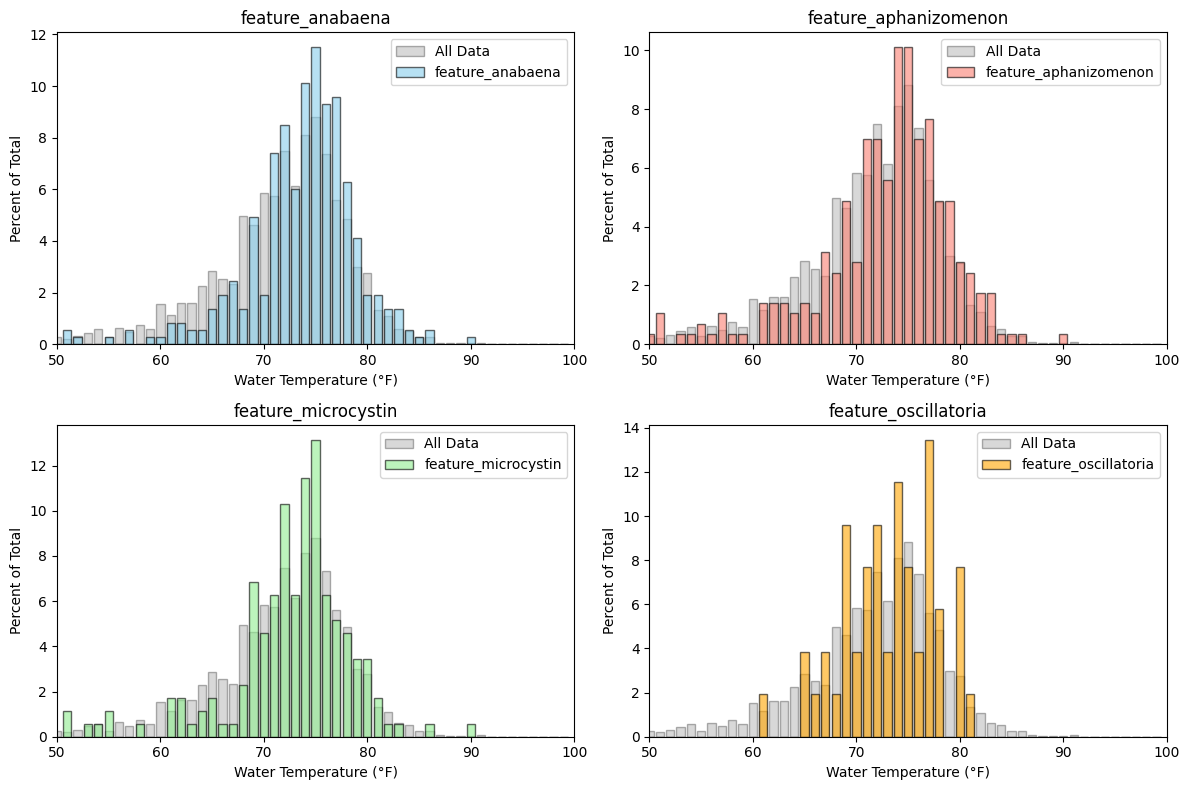

In [ ]:
# Columns to plot
y_cols = ["feature_anabaena", "feature_aphanizomenon",
          "feature_microcystin", "feature_oscillatoria"]

# Ensure numeric
plot_df = vct_bloom_df[["feature_water_temp"] + y_cols].apply(pd.to_numeric, errors="coerce")

# Filter for temperature range 50–100
plot_df = plot_df[(plot_df["feature_water_temp"] >= 50) & (plot_df["feature_water_temp"] <= 100)]

# Define 1-degree bins
bins = np.arange(50, 101, 1)
bin_width = 1

# Overall data percentage per bin
hist_all_counts, _ = np.histogram(plot_df["feature_water_temp"], bins=bins)
hist_all_percent = hist_all_counts / hist_all_counts.sum() * 100

# Features: sum per bin, converted to % of total feature sum
hist_features_percent = {}
for col in y_cols:
    feature_sum_per_bin = plot_df.groupby(pd.cut(plot_df["feature_water_temp"], bins=bins))[col].sum().values
    total = feature_sum_per_bin.sum()
    hist_features_percent[col] = feature_sum_per_bin / total * 100 if total > 0 else np.zeros_like(feature_sum_per_bin)

# Create subplots: one for each feature
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

colors = ["skyblue", "salmon", "lightgreen", "orange"]

for ax, col, color in zip(axes, y_cols, colors):
    # Plot overall data in gray
    ax.bar(bins[:-1], hist_all_percent, width=0.8, alpha=0.3, label="All Data", color="gray", edgecolor="black")
    # Plot feature
    ax.bar(bins[:-1], hist_features_percent[col], width=0.8, alpha=0.6, label=col, color=color, edgecolor="black")
    
    ax.set_xlim(50, 100)
    ax.set_xlabel("Water Temperature (°F)")
    ax.set_ylabel("Percent of Total")
    ax.set_title(col)
    ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Compute correlation coefficients for every number variable

corr_cols = ["Water Temperature", "Density", "Microcystin"]

corr_matrix = safe_plot_df.corr()

for corr_col in corr_cols:
    print(corr_matrix[corr_col].sort_values(ascending=False).round(2), "\n")


In [ ]:
# Calculate scatterplots for every number variable pair

use_log_values = True

scatter_cols = ["Water Temperature", "Density", "Microcystin"]
plot_df = algae_bloom_df[scatter_cols].apply(pd.to_numeric, errors="coerce")

# Compute logs if needed
if use_log_values:
    safe_plot_df = plot_df.where(plot_df > -1)
    safe_plot_df = np.log10(safe_plot_df + 1)
else:
    safe_plot_df = plot_df.copy()
    
axes = scatter_matrix(safe_plot_df[scatter_cols], figsize=(9,7), alpha=0.9)

for ax in axes.flatten():
    
    ax.tick_params(axis="x", labelsize=7)
    ax.tick_params(axis="y", labelsize=7)
    xlabel = ax.get_xlabel()
    wrapped_xlabel = "\n".join(textwrap.wrap(xlabel, width=20))
    ax.set_xlabel(wrapped_xlabel, fontsize=8)
    ylabel = ax.get_ylabel()
    wrapped_ylabel = "\n".join(textwrap.wrap(ylabel, width=20))
    ax.set_ylabel(wrapped_ylabel, fontsize=8)

plt.subplots_adjust(hspace=0.2, wspace=0.2)

plt.show()